In [1]:
import numpy as np
import matplotlib.pyplot as plt

from joblib import Parallel, delayed

import schwingerModel as sim

from schwingerModel.interpolator import MesonOp, mesonMultiplet, makeState

from schwingerModel.distillation_gpu import generateDistillFile

def triplet(op):                      
    return mesonMultiplet(op, 1)[+1]

def singlet(op):                       
    return mesonMultiplet(op, 0)[0]

In [2]:
paths = [f"./configs/dwf_beta_3.0_m_0.05_Nx_{Nx}_Nt_64_N5_16.h5" for Nx in [8,16,32,48,64]]

outPaths = [f"./configs/dwf_beta_3.0_m_0.05_Nx_{Nx}_Nt_64_N5_16.hdf5" for Nx in [8,16,32,48,64]]

numVecs = [2,2,4,6,2]

for i in range(len(paths)):
    generateDistillFile(paths[i],outPaths[i],numVecs=numVecs[i],autocorrSkip=200,
                        DNums=(0,2))

In [3]:
metas = [sim.distillation.readDistillMeta(p) for p in outPaths]

In [4]:
pionBasis = [triplet(MesonOp("g5")),triplet(MesonOp("g5",DNum=2))]

In [5]:
pionCorrels = [sim.GEVP.measureEnsemble(outPaths[i],metas[i].configIndices,pionBasis) for i in range(len(metas))]

Measuring configs: 100%|██████████| 100/100 [00:00<00:00, 747.31it/s]


In [6]:
gevpTi = 2

# one worker per volume; progress=False because worker tqdm bars don't reach the notebook
pionPrinCorresl = Parallel(n_jobs=len(pionCorrels))(
    delayed(sim.GEVP.bootstrapEnsemble)(pC, reduce=sim.GEVP.makeGevpReduce(ti=gevpTi, shift=1),
                                        progress=False)
    for pC in pionCorrels)

In [12]:
fitTs = [[5,30],[5,30],[5,30],[5,30],[5,30]]

pionMasses = Parallel(n_jobs=len(pionCorrels))(
    delayed(sim.GEVP.bootstrapEnsemble)(pionCorrels[i],
                                        reduce=sim.GEVP.massReduce(ti=gevpTi, shift=1,
                                                                   withAmp=True, fitT=fitTs[i],
                                                                   fitForm="sinh"),
                                        progress=False)
    for i in range(len(pionCorrels)))

# the same model for the plots: MUST match massReduce's form/ti/shift
fitModels = [sim.plotting.fitCurve("sinh", ti=gevpTi, shift=1, dimt=m.dimt) for m in metas]

(<Figure size 1600x840 with 8 Axes>,
 array([<Axes: title={'center': '$N_x = 8$'}, ylabel='$|\\lambda^{(s)}(t)|$'>,
        <Axes: title={'center': '$N_x = 16$'}, xlabel='$(t - t_i)/a$'>,
        <Axes: title={'center': '$N_x = 32$'}, xlabel='$(t - t_i)/a$'>,
        <Axes: title={'center': '$N_x = 48$'}, xlabel='$(t - t_i)/a$'>,
        <Axes: title={'center': '$N_x = 64$'}, xlabel='$(t - t_i)/a$', ylabel='$|\\lambda^{(s)}(t)|$'>],
       dtype=object))

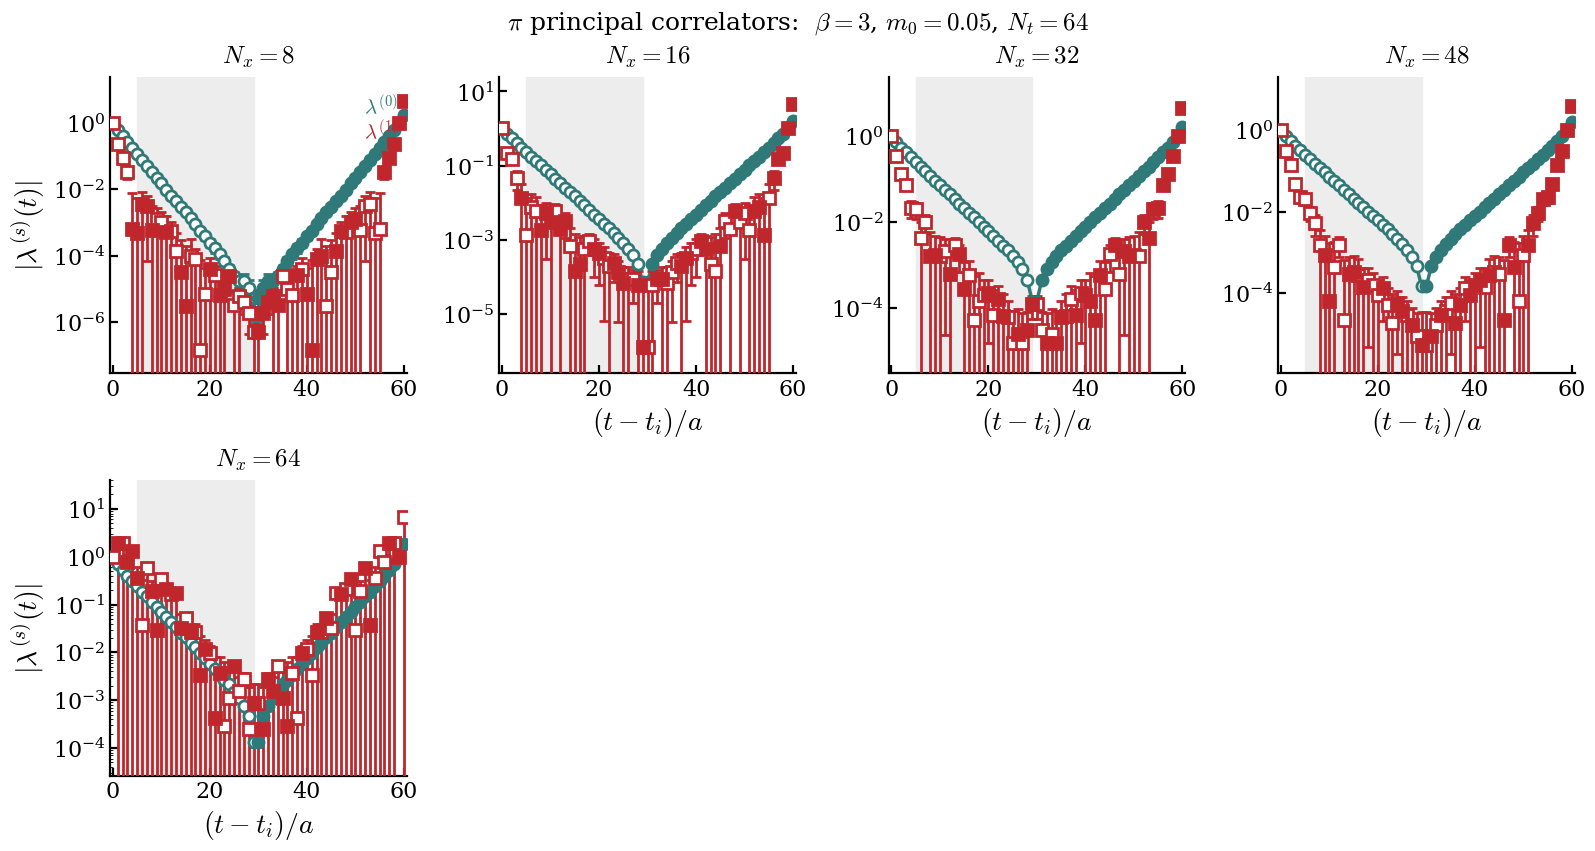

In [13]:
# raw principal correlators on a log axis, fitted sinh overlaid: straight
# where the ground state dominates; the sinh cusp shows as the dive at T/2
sim.plotting.prinCorrelSemilog(
    pionPrinCorresl,
    masses=pionMasses,
    fitT=fitTs,
    fitModel=fitModels[0],
    labels=[rf"$N_x = {m.dimx}$" for m in metas],
    title=rf"$\pi$ principal correlators:  $\beta = {float(metas[0].beta):g}$, "
          rf"$m_0 = {float(metas[0].fMass):g}$, $N_t = {metas[0].dimt}$")

(<Figure size 1600x840 with 8 Axes>,
 array([<Axes: title={'center': '$N_x = 8$'}, ylabel='$\\lambda^{(0)}(t) \\, / \\, \\mathrm{fit}$'>,
        <Axes: title={'center': '$N_x = 16$'}, xlabel='$(t - t_i)/a$'>,
        <Axes: title={'center': '$N_x = 32$'}, xlabel='$(t - t_i)/a$'>,
        <Axes: title={'center': '$N_x = 48$'}, xlabel='$(t - t_i)/a$'>,
        <Axes: title={'center': '$N_x = 64$'}, xlabel='$(t - t_i)/a$', ylabel='$\\lambda^{(0)}(t) \\, / \\, \\mathrm{fit}$'>],
       dtype=object))

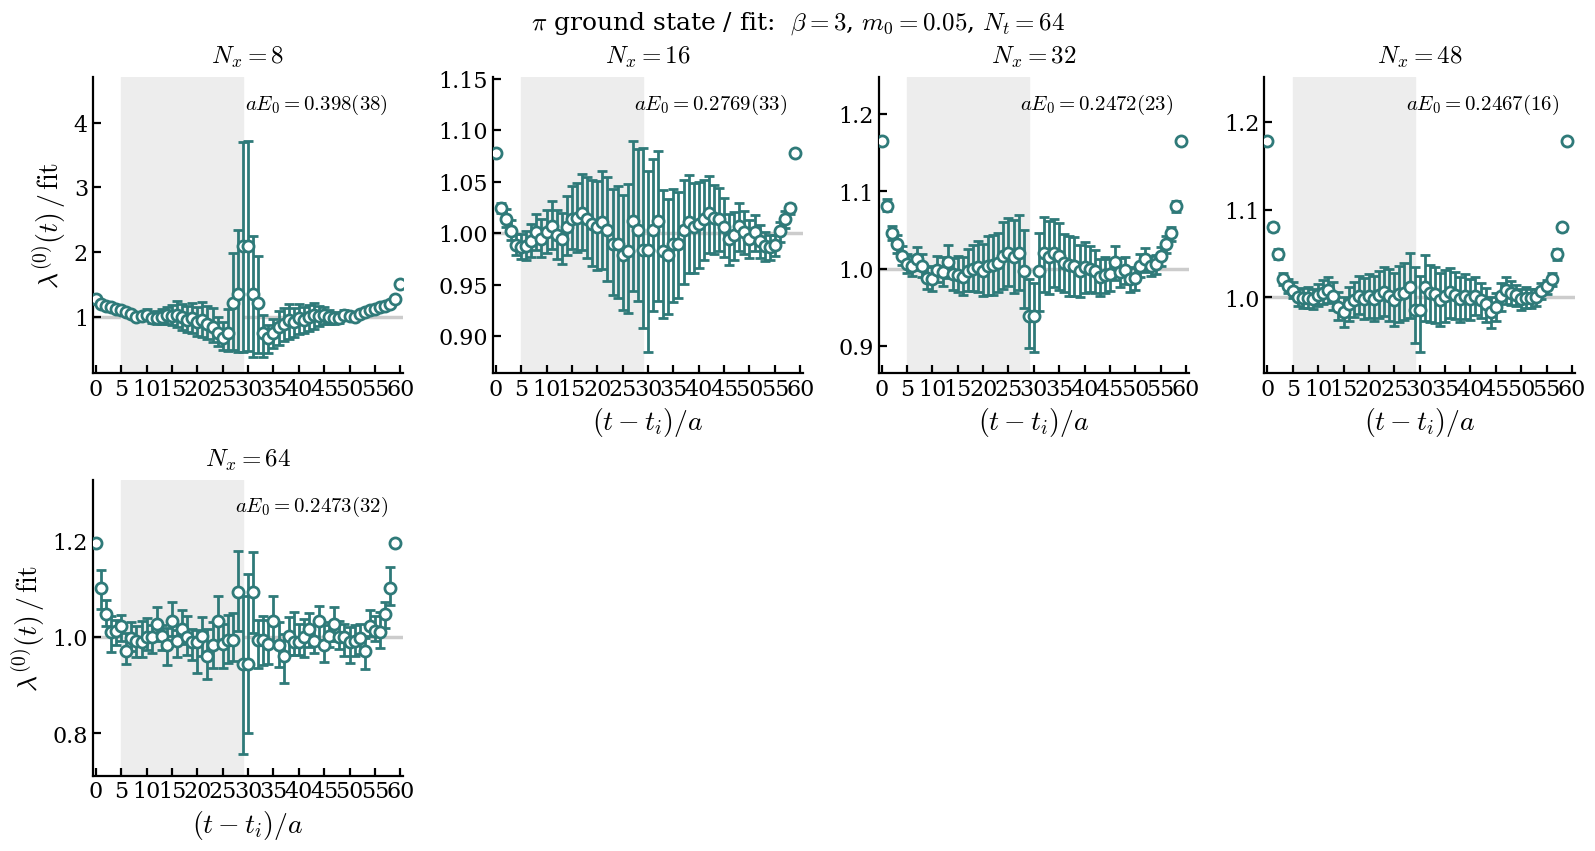

In [14]:
# fit quality per volume: lambda(t) / fit flattens to 1 wherever the sinh
# describes the data; deviations at small t are excited states, and points
# outside the shaded fit window carry no obligation to sit at 1
sim.plotting.prinCorrelOverFit(
    pionPrinCorresl, pionMasses,
    state=0,
    fitT=fitTs,
    fitModel=fitModels[0],
    labels=[rf"$N_x = {m.dimx}$" for m in metas],
    title=rf"$\pi$ ground state / fit:  $\beta = {float(metas[0].beta):g}$, "
          rf"$m_0 = {float(metas[0].fMass):g}$, $N_t = {metas[0].dimt}$")


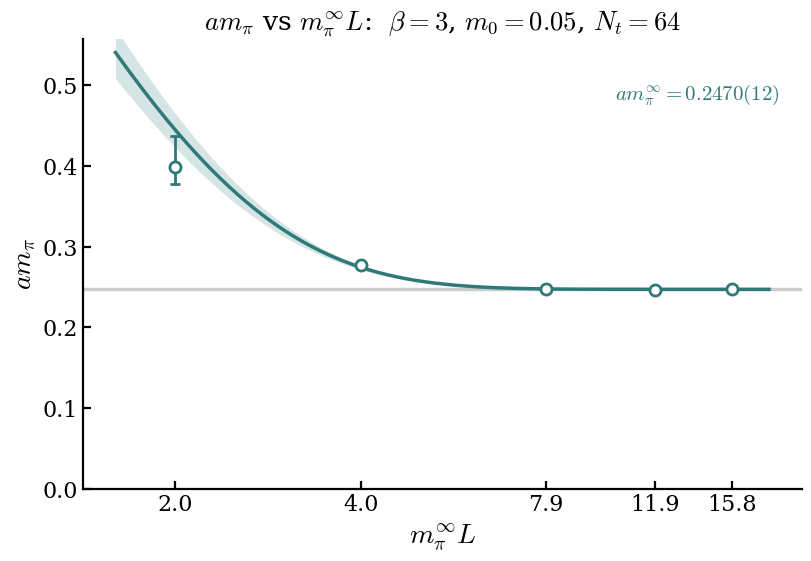

: 

In [ ]:
from scipy.optimize import curve_fit
from schwingerModel import plotting as sp

# finite-volume fit: m(L) = m_inf + A e^{-m_inf L}, self-consistent exponent
Nxs = np.array([m.dimx for m in metas], dtype=float)
aM = np.array([pm[0][0, 0] for pm in pionMasses])                 # ground-state aE0
aMerrRows = np.array([pm[1][:, 0, 0] for pm in pionMasses]).T     # (2, n): [high-c, c-low]
sigma = np.max(np.clip(aMerrRows, 1e-12, None), axis=0)           # symmetrized for the fit

def fvModel(L, mInf, A):
    return mInf + A * np.exp(-mInf * L)

popt, pcov = curve_fit(fvModel, Nxs, aM, p0=(aM[-1], 1.0), sigma=sigma, absolute_sigma=True)
mInf, dmInf = popt[0], np.sqrt(pcov[0, 0])

# fit band from the parameter covariance
Lgrid = np.linspace(0.8 * Nxs[0], 1.15 * Nxs[-1], 400)
draws = np.random.default_rng(0).multivariate_normal(popt, pcov, size=1000)
bandLo, bandHi = np.percentile(np.array([fvModel(Lgrid, *d) for d in draws]), [16, 84], axis=0)

fig, ax = plt.subplots(figsize=(8, 5.5), layout="constrained")
ax.axhline(mInf, color=sp.GREY, lw=sp.LW, zorder=0)               # fitted asymptote
ax.fill_between(mInf * Lgrid, bandLo, bandHi, color=sp.JLab_blue, alpha=0.20, lw=0, zorder=1)
ax.plot(mInf * Lgrid, fvModel(Lgrid, *popt), color=sp.JLab_blue, lw=sp.LW, zorder=2)
ax.errorbar(mInf * Nxs, aM, yerr=np.clip(aMerrRows, 0, None)[::-1],
            marker="o", color=sp.JLab_blue, mec=sp.JLab_blue, **sp.eb_kw)

ax.set_xscale("log")
ax.set_xticks(mInf * Nxs)
ax.set_xticklabels([f"{v:.1f}" for v in mInf * Nxs])
ax.minorticks_off()
ax.set_ylim(0, 1.4 * aM.max())
ax.set_xlabel(r"$m_\pi^\infty L$")
ax.set_ylabel(r"$a m_\pi$")
ax.text(0.97, 0.85, rf"$a m_\pi^\infty = {sp.fmtErr(mInf, dmInf)}$", color=sp.JLab_blue,
        ha="right", va="bottom", transform=ax.transAxes, fontsize=15, zorder=5, bbox=sp.TEXTBOX)
ax.set_title(rf"$am_\pi$ vs $m_\pi^\infty L$:  $\beta = {float(metas[0].beta):g}$, "
             rf"$m_0 = {float(metas[0].fMass):g}$, $N_t = {metas[0].dimt}$")

fig.savefig(f"figs/pionMassVsMpiL_beta{float(metas[0].beta):g}"
            f"_m{float(metas[0].fMass):g}_Nt{metas[0].dimt}.pdf")